In [2]:
import sys
sys.path.append('../../Data/')
sys.path.append('Utils/')
from cycleGRN import bin_traj, train_ours,traj_ours,build_laplacian,find_Lie_derivative, velocity_streamplot
from cycleGRN import time_lagged_correlation, time_lagged_Granger, time_lagged_Granger_CV_fast,pick_k_threshold
import cellrank as cr
import anndata as ad
import scanpy as sc
import pandas as pd
import scvelo as scv
from spatial_velocity import project_velocity_spatial, find_diffusion_time, velocity_streamplot_spatial,orient_flow_by_cell_cycle_phase
# from cyclic_pseudotime import find_diffusion_time
%load_ext autoreload
%autoreload 2

# Load mouse dorsal midbrain data

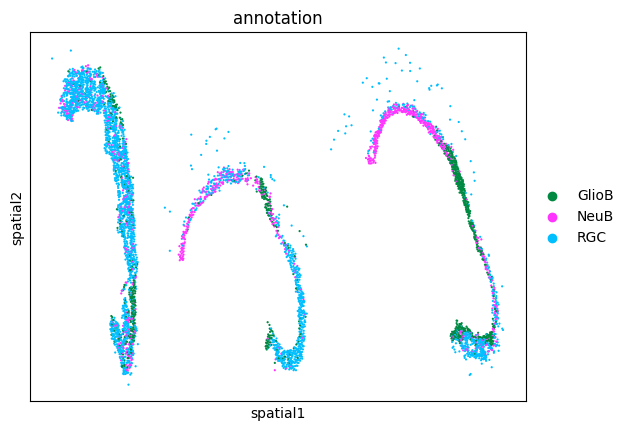

In [4]:
adata = ad.read_h5ad('../../Data/dorsal_midbrain_processed.h5ad')
adata.X = adata.layers['counts'].copy()
sc.pp.highly_variable_genes(adata, n_top_genes = 2000)
sc.pp.normalize_total(adata, target_sum=1e4)  # library-size normalize
sc.pp.log1p(adata)

cell_cycle_genes = pd.read_csv('../../Data/GO_cycle_genes_mouse.txt', sep=None, engine="python")
genes_subset = list(set(list( cell_cycle_genes['MGI Gene/Marker ID'].values ) ) )
sc.tl.pca(adata, n_comps=50, svd_solver="arpack")  # or "randomized" for speed
gene_mask = adata.var_names.isin(genes_subset)
adata_subset = adata[:, gene_mask].copy()
adata_subset 
import scanpy as sc

# PCA
sc.tl.pca(adata_subset, n_comps=50, svd_solver="arpack")  # or "randomized" for speed
import scanpy as sc

sc.pl.embedding(
    adata,
    color='annotation',
    basis='spatial',
    size=10,
    # spot_size = 10,
)
adata_rgc = adata[ adata.obs['annotation'] == 'RGC' ]

# Prepare for CYCLO

(2760, 2)
(2760, 2)


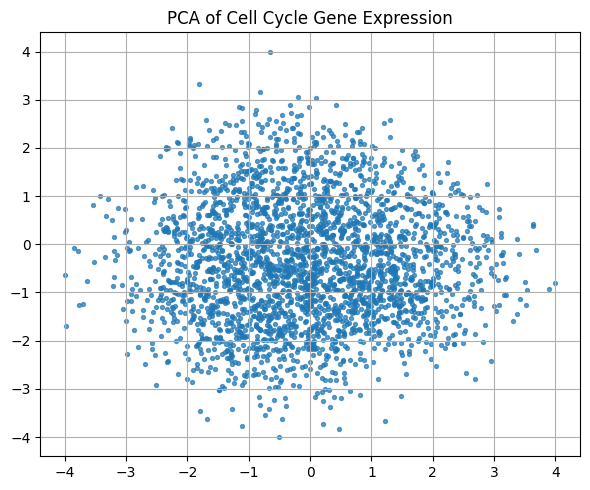

In [11]:
adata_rgc = adata[ adata.obs['annotation'] == 'RGC' ]
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

gene_mask = adata.var_names.isin(genes_subset)
adata_rgc_subset = adata_rgc[:, gene_mask].copy()
sc.tl.pca(adata_rgc_subset, n_comps=10, svd_solver="arpack")  # or "randomized" for speed
subsample = np.where( adata_rgc.obs['time'] < 100 )[0]
# Standardize the data
pca_result = adata_rgc_subset[subsample].obsm['X_pca'][:,0:2]
# pca_result = np.vstack( [tricycle['tricycle_dim1'].values, tricycle['tricycle_dim2'].values]).T

print( pca_result.shape )

ys_true = (pca_result[:, :2] - pca_result[:, :2].min(0)) / np.ptp(pca_result[:, :2],0) * [8, 8] - [4, 4]
print(ys_true.shape)

# Plot
plt.figure(figsize=(6, 5))
plt.scatter(ys_true[:, 0], ys_true[:, 1], s=8, alpha=0.7)
plt.title("PCA of Cell Cycle Gene Expression")
# plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
# plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.grid(True)
plt.tight_layout()
plt.show()
import pickle
with open('../../Data/spatial_PC.p', "wb") as f:
    pickle.dump([[0],ys_true], f)

In [13]:
ys2,ts2,vs2 = traj_ours(1000,'../../Data/spatial_PC.p',seed=0)
import scipy
X = adata_rgc_subset.X.T
T = build_laplacian(ys_true, vs2,X_full=None, k=200, threshold=0., stimulation=False)
T = T.todense()
# T, _ = orient_flow_by_cell_cycle_phase(
#     adata_subset[subsample],
#     T)
T = scipy.sparse.csr_matrix(T)

# T = T.T
T, _ = orient_flow_by_cell_cycle_phase(adata_rgc, T)  # Changed from adata_rgc_subset
T_full = scipy.sparse.csr_matrix(T)
V_overall, V_mask, V_gated = project_velocity_spatial(adata_rgc_subset, T, k=200)




Plotting Dynamics
Plotting Inferred Parameter
[orient_flow] P (rows: from, cols: to) in order ('G1', 'S', 'G2M')
[[0.174 0.238 0.588]
 [0.104 0.288 0.607]
 [0.109 0.268 0.623]]
[orient_flow] drift = -0.0019  (positive = forward)
[orient_flow] drift<0, returning T.T to orient forward.


In [19]:
tricycle = pd.read_csv("../../Data/tricycle_spatial.csv")
adata_rgc.obs['Cell_cycle_relativePos'] = tricycle['tricycle_theta'].values

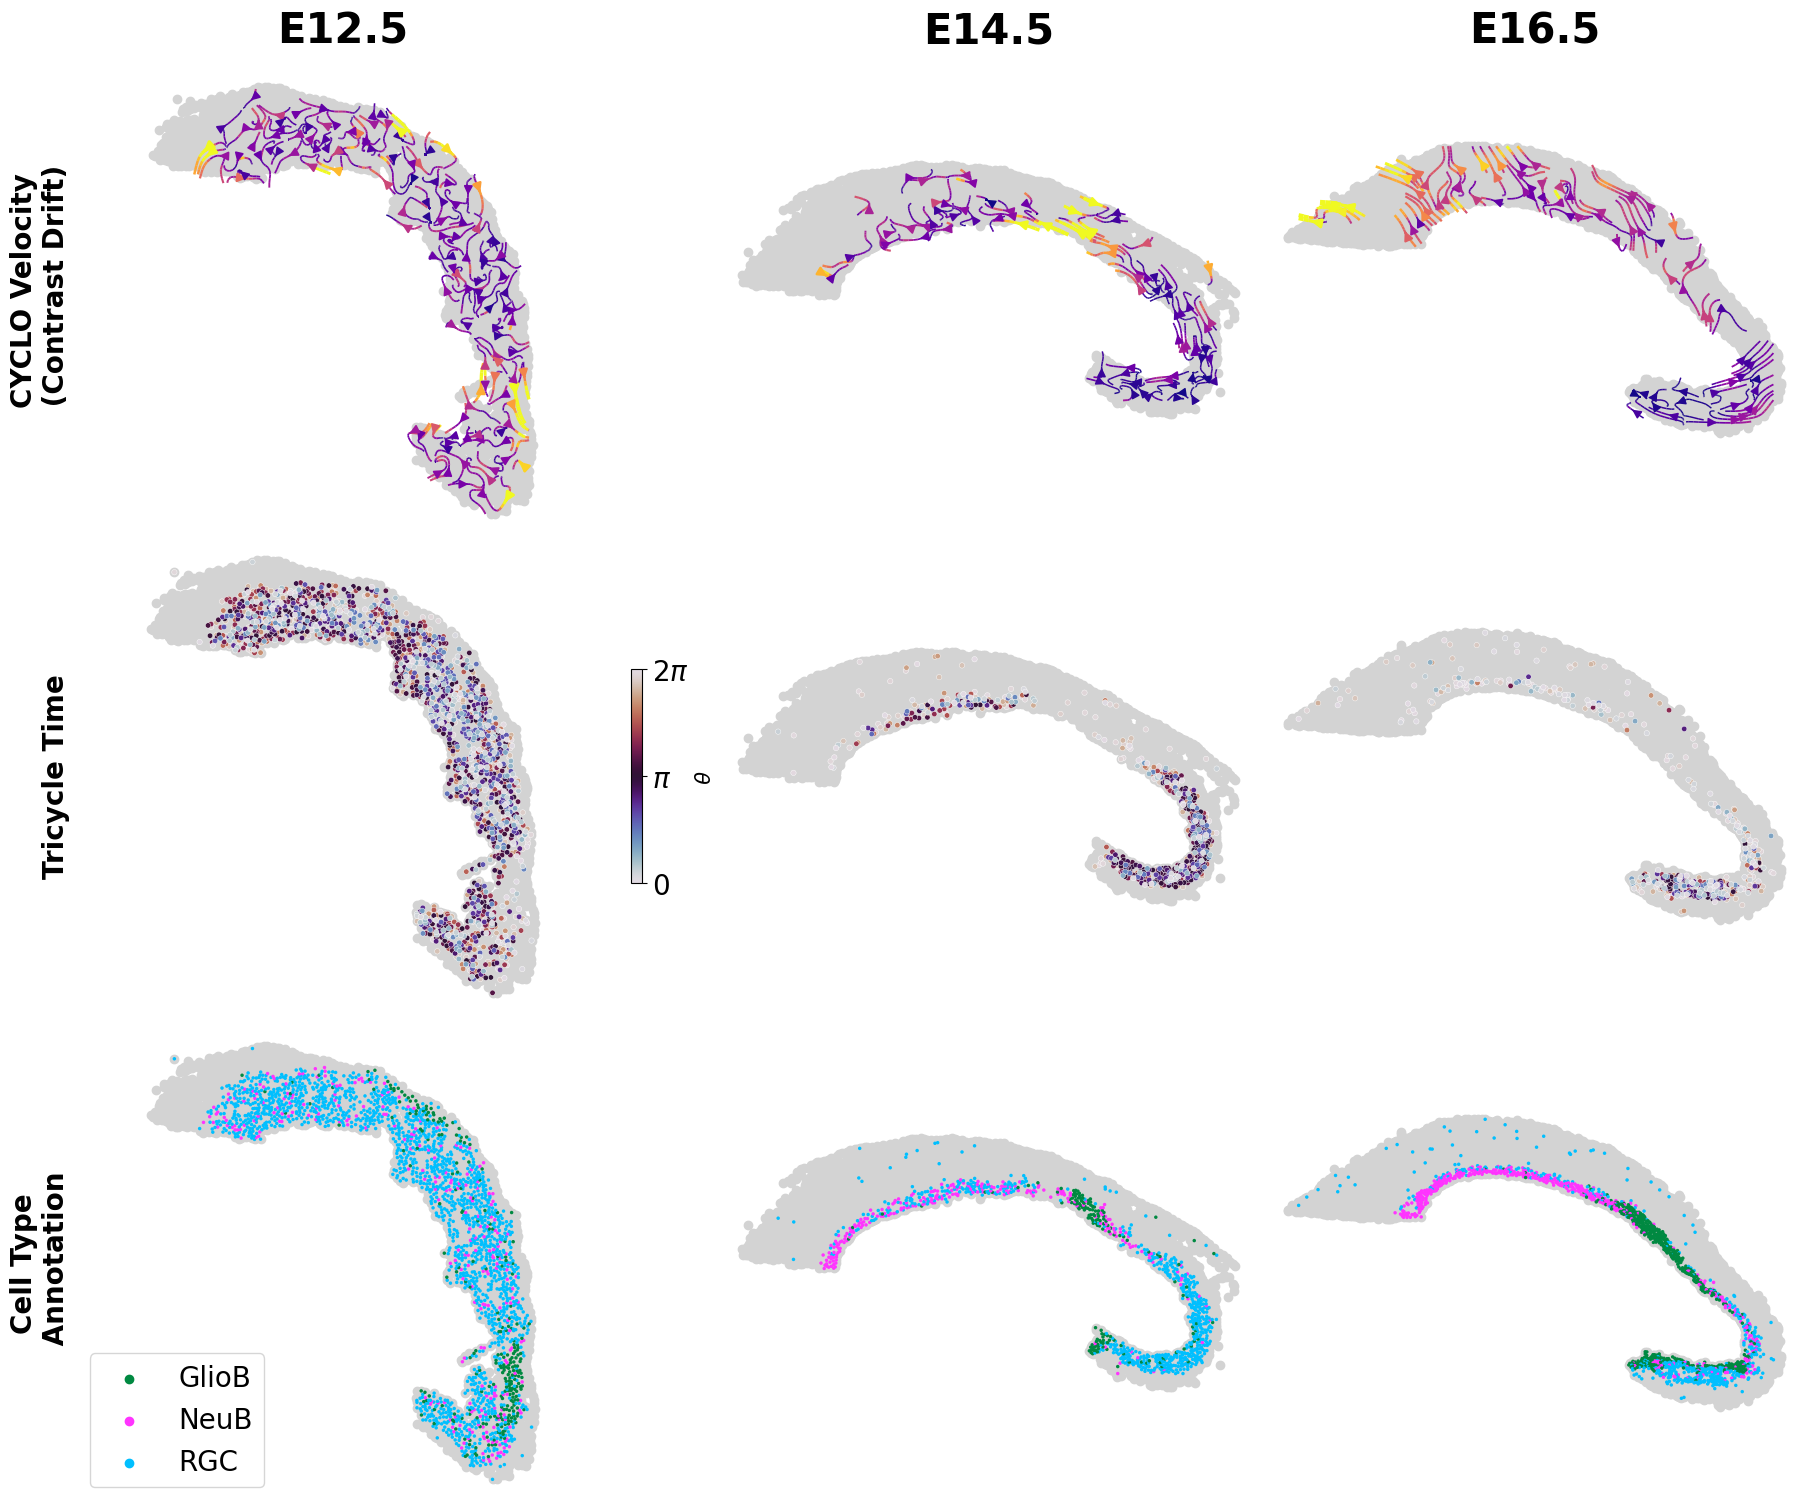

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import scipy.sparse

# Get global min/max for Top2a
vmax_gene = np.percentile(np.array(adata[:, 'Top2a'].X.todense()).ravel(), 99)
vmin_gene = 0

times = [12.5, 14.5, 16.5]

# --- 2. PLOTTING SETUP ---
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15), constrained_layout=True)
cols = ["CYCLO Velocity\n (Contrast Drift)", "Tricycle Time","Cell Type\n Annotation"]


# --- 3. MAIN LOOP ---
for i, time in enumerate(times):
    # Subset data
    subsample_idx = np.where(adata_rgc.obs['time'] == time)[0]
    adata_sub = adata_rgc[subsample_idx].copy()
    
    # Slice transition matrix (safe now that T_full and subsample_idx use same adata_rgc)
    T_sub = T_full[np.ix_(subsample_idx, subsample_idx)]
    
    # --- COL 1: VELOCITY ---
    ax_vel = axes[0,i]
    V_overall, V_mask, V_gated = project_velocity_spatial(adata_sub, T_sub, k=200)
    # _, _, V_overall = project_velocity_spatial(adata_sub, T_sub, k=200)
    # V_overall = find_Lie_derivative(adata_rgc[subsample_idx].obsm['spatial'].T, T_sub, stimulation=False)
    spatial = pd.read_csv('../../Data/Slice_'+str(i)+'_location.csv')
    # ax_vel.scatter( adata_sub.obsm['spatial'][:, 0],
    #     adata_sub.obsm['spatial'][:, 1], c='lightgray')
    ax_vel.scatter( spatial['x'], spatial['y'], c='lightgray')
    velocity_streamplot_spatial(
        adata_sub.obsm['spatial'][:, 0],
        adata_sub.obsm['spatial'][:, 1],
        np.asarray(V_overall[0, :]).reshape(-1),
        np.asarray(V_overall[1, :]).reshape(-1), 
        smooth_sigma=0.8,
        gridsize=100,
        density=3.,
        min_count=1,
        linewidth_range=(1.0,2.0),
        ax=ax_vel
    )
    
    
    
    ax_vel.set_title(f"E{time}", fontsize=30, fontweight='bold')#, rotation=90, labelpad=20)
    ax_vel.axis('equal')
    ax_vel.set_frame_on(False)
    if i == 0:
        ax_vel.set_ylabel(cols[0], fontsize=20, fontweight='bold', rotation=90)
        
    # --- COL 2: ANNOTATION (FIXED) ---
    ax_ano = axes[2,i]
    ax_ano.scatter( spatial['x'], spatial['y'], c='lightgray')
    if i == 0:
        sc.pl.embedding(
            adata[adata.obs['time']==time],               # <--- This was the likely break
            basis="spatial",
            color="annotation",
            size=30,
            ax=ax_ano,
            show=False,
            legend_loc='best',#'on data',
            legend_fontsize=20,
            title='',
            s=25
        )
    else:
        sc.pl.embedding(
            adata[adata.obs['time']==time],               # <--- This was the likely break
            basis="spatial",
            color="annotation",
            size=30,
            ax=ax_ano,
            show=False,
            title='',
            s=25,
            legend_loc='none'
        )
    ax_ano.axis('equal')
    if i == 0:
        ax_ano.set_ylabel(cols[2], fontsize=20, fontweight='bold')
        ax_ano.set_xlabel('')
    else:
        ax_ano.set_ylabel('')
        ax_ano.set_xlabel('')
    ax_ano.set_frame_on(False)
    
    # --- COL 4: GENE EXPRESSION ---
    ax_gene = axes[1,i]
    gene_expr = np.array(tricycle['tricycle_theta'].iloc[subsample_idx]).ravel()
    # gene_expr = np.array(adata_sub[:, 'Top2a'].layers['counts'].todense()).ravel()
    # gene_expr = tau[subsample_idx]
    order = np.argsort(-gene_expr)
    # ax_gene.scatter( adata_sub.obsm['spatial'][:, 0],
    #     adata_sub.obsm['spatial'][:, 1], c='lightgray')
    ax_gene.scatter( spatial['x'], spatial['y'], c='lightgray')
    scat = ax_gene.scatter(
        adata_sub.obsm['spatial'][order, 0],
        adata_sub.obsm['spatial'][order, 1],
        c= gene_expr[order],
        s=15,
        cmap='twilight',
        edgecolors='white',
        vmin=gene_expr.min(),
        vmax=gene_expr.max(),
        linewidths=0.3,
        zorder=2
    )
    ax_gene.axis('equal')
    ax_gene.set_frame_on(False)
    # ax_gene.axis('off')

    if i == 0:
        # cbar = plt.colorbar(scat, ax=ax_gene, fraction=0.046, pad=0.04)
        cbar = plt.colorbar(scat, ax=ax_gene, fraction=0.02, pad=0.04, location='right')
        cbar.set_label(r'$\theta$', rotation=270, labelpad=15,fontsize=15)
        
        cbar.set_ticks([0, np.pi, 2 * np.pi])
    
        cbar.set_ticklabels(['0', r'$\pi$', r'$2\pi$'])
        cbar.ax.tick_params(labelsize=20)
     
        ax_gene.set_ylabel(cols[1], fontsize=20, fontweight='bold')

# for ax, col in zip(axes[:,0], cols):
#     ax.set_ylabel(col, fontsize=30, fontweight='bold',rotation=90)#, pad=20)
    
# --- 4. CLEANUP ---
for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

# plt.savefig('../Figures/spatial.pdf',bbox_inches='tight')
plt.show()

# Compare coherence

In [21]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

def calculate_coherence_robust(adata, V_array):
    """
    Calculates local flow coherence on a specific subset.
    Always recomputes neighbors to ensure local topology is used.
    """
    
    # --- Step 1: Compute Neighbors Locally ---
    # We force recomputation here to ensure the graph only contains 
    # edges between cells in this specific slice.
    sc.pp.neighbors(adata,use_rep='spatial') 

    # --- Step 2: Prepare Velocity Array ---
    # Check shapes
    if V_array.shape[0] != adata.n_obs:
        raise ValueError(f"Shape mismatch! Array has {V_array.shape[0]} cells, adata has {adata.n_obs}.")
    
    # Normalize vectors (Direction only, ignore magnitude)
    norms = np.linalg.norm(V_array, axis=1, keepdims=True) + 1e-8
    V_norm = V_array / norms
    
    # --- Step 3: Calculate Coherence ---
    # Get the adjacency matrix (who is next to whom)
    if 'connectivities' not in adata.obsp:
         raise ValueError("Connectivities not found even after running neighbors.")
         
    # A = adata.obsp['connectivities']
    
    # # Calculate Consensus Vector (Average of neighbors)
    # V_neighbors = A @ V_norm
    
    A = adata.obsp['connectivities'].tocsr().copy()
    A.setdiag(0)
    A.eliminate_zeros()
    V_neighbors = A @ V_norm

    
    # Normalize the consensus
    n_norms = np.linalg.norm(V_neighbors, axis=1, keepdims=True) + 1e-8
    V_consensus = V_neighbors / n_norms
    
    # Dot product = Cosine Similarity (-1 to 1)
    coherence = np.sum(V_norm * V_consensus, axis=1)
    
    return coherence

# --- USAGE WITH SLICING ---

V_overall, V_mask, V_gated = project_velocity_spatial(adata_rgc, T_full, k=200)
V_full = V_overall.T

# 2. Create a container for the results
# We use a Series indexed by cell names to ensure alignment
coherence_scores = pd.Series(index=adata_rgc.obs_names, dtype=float)

# 3. Loop through each time point separately
unique_times = np.sort(adata_rgc.obs['time'].unique())

for t in unique_times:
    print(f"Processing time point: {t}...")
    
    # A. Identify cells belonging to this time point
    mask = adata_rgc.obs['time'] == t
    
    # B. Subset the AnnData object (creates a copy)
    adata_slice = adata_rgc[mask].copy()
    
    # C. Subset the Velocity Array using the same mask
    V_slice = V_full[mask,:]
    
    # D. Calculate Coherence (Neighbors will be computed inside)
    scores = calculate_coherence_robust(adata_slice, V_slice)
    
    # E. Store results back in the main container
    coherence_scores.loc[mask] = scores

# 4. Save to the main object
adata_rgc.obs['flow_coherence_split'] = coherence_scores

from scipy.stats import mannwhitneyu

# Extract the scores for each time point
scores_12 = adata_rgc[adata_rgc.obs['time'] == 12.5].obs['flow_coherence_split']
scores_14 = adata_rgc[adata_rgc.obs['time'] == 14.5].obs['flow_coherence_split']
scores_16 = adata_rgc[adata_rgc.obs['time'] == 16.5].obs['flow_coherence_split']

print(f"--- Statistical Significance (Mann-Whitney U) ---")

# Compare E12.5 vs E14.5 (The "Onset" of Laminar Flow)
stat, p_val12 = mannwhitneyu(scores_12, scores_14, alternative='less') 
print(f"E12.5 < E14.5: p-value = {p_val12:.2e}")

# Compare E12.5 vs E16.5 (The Full Transition)
stat, p_val13 = mannwhitneyu(scores_12, scores_16, alternative='less')
print(f"E12.5 < E16.5: p-value = {p_val13:.2e}")

# Compare E12.5 vs E16.5 (The Full Transition)
stat, p_val23 = mannwhitneyu(scores_14, scores_16, alternative='less')
print(f"E14.5 < E16.5: p-value = {p_val23:.2e}")

Processing time point: 12.5...
Processing time point: 14.5...
Processing time point: 16.5...
--- Statistical Significance (Mann-Whitney U) ---
E12.5 < E14.5: p-value = 6.10e-04
E12.5 < E16.5: p-value = 1.31e-15
E14.5 < E16.5: p-value = 5.68e-04


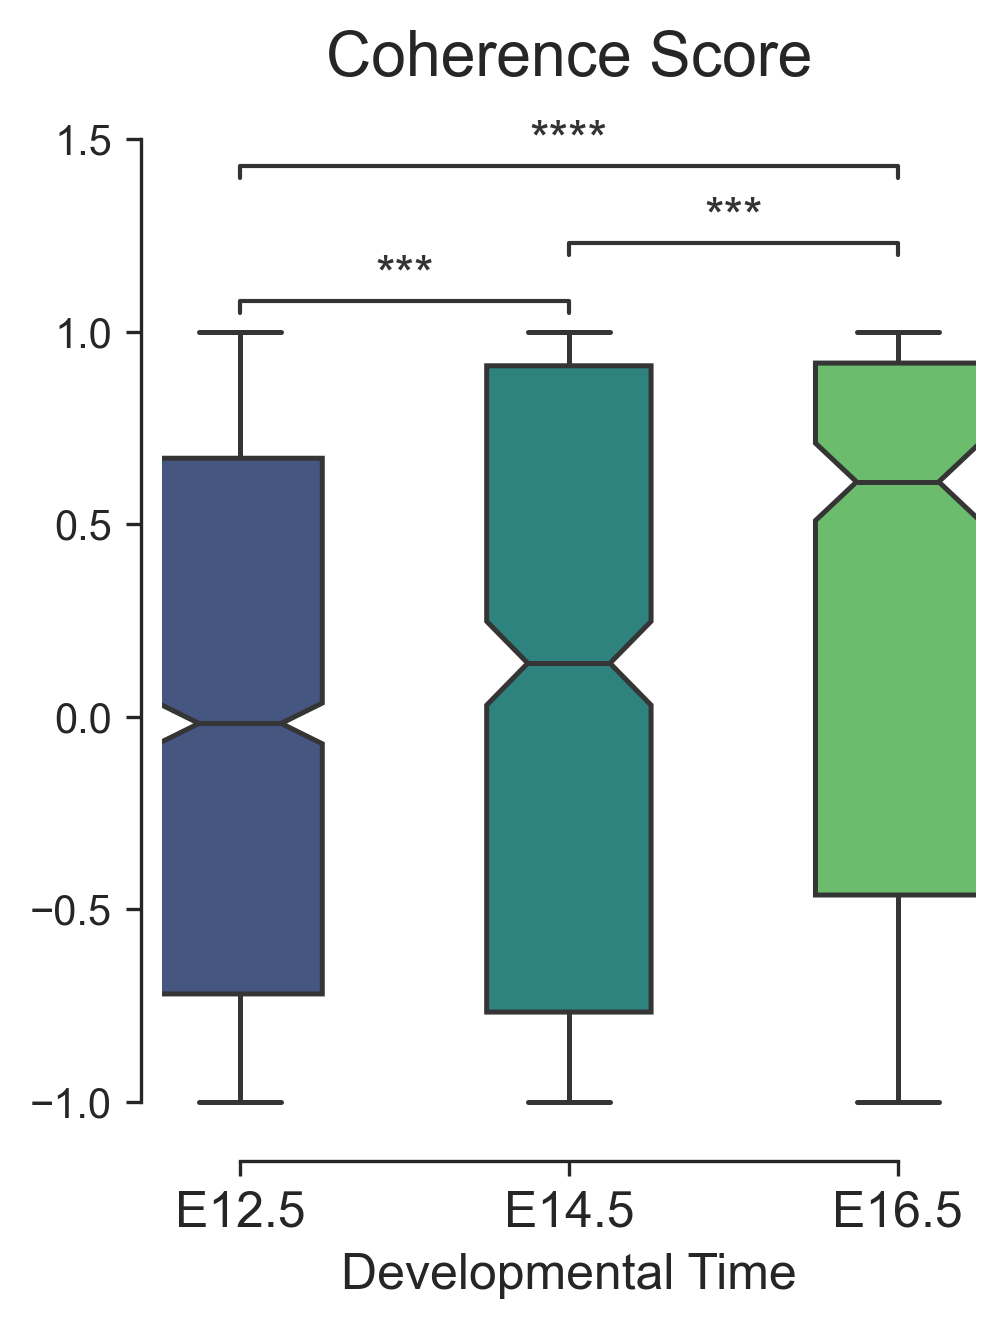

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size']=10
plt.figure(figsize=(3.5, 4.5)) # Slightly more compact

# 2. Draw Boxplot
ax = sns.boxplot(
    data=adata_rgc.obs, 
    x='time', 
    y='flow_coherence_split', 
    palette='viridis',
    notch=True,
    width=0.5,       
    linewidth=1.2,   
    fliersize=0,     # Hiding outliers makes the box shape clearer
    showcaps=True    
)

# 3. Define the Bracket Function (Refined for spacing)
def add_stat_annotation(ax, x1, x2, p_val, y_pos):
    h = 0.03 # Lower bracket height for sleekness
    col = '0.2'
    lw = 1.0   
    
    # Determine star
    if p_val < 0.0001: star = "****"
    elif p_val < 0.001: star = "***"
    elif p_val < 0.01: star = "**"
    elif p_val < 0.05: star = "*"
    else: star = "ns"
    
    # Draw bracket
    plt.plot([x1, x1, x2, x2], [y_pos, y_pos+h, y_pos+h, y_pos], lw=lw, c=col)
    
    # Add text (Font size 12 is usually perfect for this)
    plt.text((x1+x2)*.5, y_pos+h, star, ha='center', va='bottom', color=col, fontsize=12)

# 4. Add Annotations (Adjusted heights to be tight)
add_stat_annotation(ax, 0, 1, p_val12, y_pos=1.05)    # E12.5 vs E14.5
add_stat_annotation(ax, 1, 2, p_val23, y_pos=1.20)    # E14.5 vs E16.5
add_stat_annotation(ax, 0, 2, p_val13, y_pos=1.40)  # E12.5 vs E16.5

# 5. Final Styling (The "Pro" Look)
sns.despine(offset=5, trim=True)

# Custom X-ticks (E12.5 instead of just 12.5)
ax.set_xticklabels(["E12.5", "E14.5", "E16.5"], fontsize=12)

# Axis Labels
# plt.ylabel("Field Coherence", fontsize=12)
plt.ylabel('')
plt.xlabel("Developmental Time", fontsize=12)
plt.title("Coherence Score", fontsize=15)

# Limits
plt.ylim(-1.1, 1.6) 

# plt.savefig('../Figures/spatial_pval.pdf', bbox_inches='tight') # Save as PDF for Illustrator
plt.show()